# TP4 :  Learning on a low budget
**Harshit, Tom, Quentin**

# Introduction

**Context :**

Assume we are in a context where few "gold" labeled data samples are available for training, say 

$$\mathcal{X}_{\text{train}} = \{(x_n,y_n)\}_{n\leq N_{\text{train}}}$$

where $N_{\text{train}}$ is small. 

A large test set $\mathcal{X}_{\text{test}}$ exists but is not accessible. 
(To make your task easier, we provide you with some data (named `test_dataset` in the code) that you can use to test your model, but you **must not** use it to train your model).

We also assume that we have a limited computational budget.

The goal of this practical session is to guide you through different methods that will help you get better results from few resources (data & compute).

In this practical, we will use the `resnet18` architecture. We will use models from the [pytorch vision hub ](https://pytorch.org/vision/stable/models.html#).

# QUESTIONS

## Grading

You will be graded on 5 questions. You will need to provide 7 files : 
1. This Notebook
2. `utils.py`
3. `last_layer_finetune.pth` (the file **must be of size less than 5Mo**)
4. `daug_resnet.pth` (the file **must be of size less than 50Mo**)
5. `final_model.pth` (the file **must be of size less than 50Mo**)
6. `drawing_lora.png`
7. `cutmix.png`

If the code you defined passes all our tests, you will get the full grade. Otherwise we  will look at the intermediate questions in the notebook to give you partial credit.



 Please provide clear and short answers between `<div class="alert alert-info">  <your answer>  </div>` tags (when it's not code).  

<div class="alert alert-info">  Example of answer  </div>

In [1]:
import os

if not os.path.exists("data"):
    os.mkdir("data")
if not os.path.exists("data/TP4_images"):
    os.mkdir("data/TP4_images")
    !cd data/TP4_images && wget -O north_dataset_train.zip  "https://nextcloud.lisn.upsaclay.fr/index.php/s/yzQRWE2YjmFn9WA/download/north_dataset_train.zip" && unzip north_dataset_train.zip
    !cd data/TP4_images && wget -O north_dataset_test.zip  "https://nextcloud.lisn.upsaclay.fr/index.php/s/zntidWrFdYsGMDm/download/north_dataset_test.zip" && unzip north_dataset_test.zip
dir_path = "data/TP4_images/"


In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torchmetrics.classification import BinaryAccuracy, Accuracy, ConfusionMatrix
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from tqdm import trange

# you can install torchmetrics with `pip install torchmetrics`

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


north_dataset = datasets.ImageFolder(
    dir_path + "north_dataset_sample",
    transform=transforms.Compose([transforms.ToTensor()]),
)
test_dataset = datasets.ImageFolder(
    dir_path + "north_dataset_test",
    transform=transforms.Compose([transforms.ToTensor()]),
)
base_model = models.resnet18()

## Question 1 : 
>  Change the last layer of the resnet model so that its size fits the problem. 

In [ ]:
# Hint 
print(base_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
print(base_model.fc) # should be a Linear layer
base_model.fc = nn.Linear(in_features=base_model.fc.in_features, out_features=2)
print(base_model.fc) # should be a Linear layer with 2 output features

Linear(in_features=512, out_features=1000, bias=True)
Linear(in_features=512, out_features=2, bias=True)


In [ ]:
assert (
    base_model.fc.out_features == 2
)  # we could also change the last layer to have 1 output. Do it with 2 so that it matches our tests procedure during grading.

## Question 2: 
> Train the last layer of a randomly initialized resnet model. Provide a function precompute_features in `utils.py` that creates a new dataset from the features precomputed by the model.

Intermediate question :  Provide the training process in the notebook with training curve. Comment on the accuracy. 

In [ ]:
def precompute_features(
    model: models.ResNet, 
    dataset: torch.utils.data.Dataset, 
    device: torch.device
) -> torch.utils.data.Dataset:
    """
    Create a new dataset with the features precomputed by the model.

    If the model is $f \circ g$ where $f$ is the last layer and $g$ is 
    the rest of the model, it is not necessary to recompute $g(x)$ at 
    each epoch as $g$ is fixed. Hence you can precompute $g(x)$ and 
    create a new dataset 
    $\mathcal{X}_{\text{train}}' = \{(g(x_n),y_n)\}_{n\leq N_{\text{train}}}$

    Arguments:
    ----------
    model: models.ResNet
        The model used to precompute the features
    dataset: torch.utils.data.Dataset
        The dataset to precompute the features from
    device: torch.device
        The device to use for the computation
    
    Returns:
    --------
    torch.utils.data.Dataset
        The new dataset with the features precomputed
    """
    model = model.to(device)
    model.eval()  # to go faster (dont compute the grads) and to set dropout as 0

    get_feats = torch.nn.Sequential(*list(model.children())[:-1]) # we remove the last layer (the one we wanna train)

    get_feats.to(device)

    feats = []
    labs = []

    dataloader = DataLoader(dataset, batch_size=64, shuffle=False)

    with torch.no_grad():
        for batch in dataloader:
            images = batch[0].to(device)
            feat = get_feats(images)
            feat = feat.view(feat.size(0), -1)
            feats.append(feat.cpu())
            labs.append(batch[1].cpu())

    features = torch.cat(feats)
    labels = torch.cat(labs)

    return TensorDataset(features, labels)


<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1986696/3117706406.py:6: SyntaxWarning: invalid escape sequence '\c'
  """


In [ ]:

def plot_losses(losses, limit_y=True):
    plt.figure(figsize=(12,6))
    plt.title("Losses")
    plt.xlabel("Epochs")
    if limit_y: plt.ylim(-0.1, 1.1)
    plt.plot(losses[0], label="train loss")
    plt.plot(losses[1], label="test loss")

    plt.plot(losses[2], label="train acc")
    plt.plot(losses[3], label="test acc")
    plt.legend()
    plt.show()
    
    table = pd.DataFrame({
        "train_loss": losses[0],
        "test_loss": losses[1],
        "train_acc": losses[2],
        "test_acc": losses[3]
    })
    # display total of 10 rows
    n = len(table)
    print(table[::n//10])


In [ ]:
def simple_trainer(model, criterion, dataloader, test_dataloader, epochs=600, lr=1e-3, device="cuda"):
    """Classical trainer for a torch model with training & test evaluation
    """
    
    
    for param in model.parameters():
        param.requires_grad = True
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
    model.to(device)

    all_loss = []
    all_loss_test = []
    all_acc = []
    all_acc_test = []

    bar = trange(epochs, desc="Training", leave=True)

    for epoch in bar:
        model.train()
        epoch_loss = 0
        correct_train = 0
        num_batches = 0
        total_train = 0

        for features, labels in dataloader:
            X, y = features.to(device), labels.to(device)
            # y_one_hot = torch.nn.functional.one_hot(y, num_classes=2).float()
            y_one_hot = y

            optimizer.zero_grad()
            pred = model(X)

            loss = criterion(pred, y_one_hot)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1

            predicted_labels = torch.argmax(pred, dim=1)
            correct_train += (predicted_labels == y).sum().item()
            total_train += y.size(0)

        avg_loss = epoch_loss / num_batches
        train_acc = correct_train / total_train

        all_loss.append(avg_loss)
        all_acc.append(train_acc)

        model.eval()
        test_loss = 0
        correct_test = 0
        total_test = 0
        num_batches_test = 0

        with torch.no_grad():
            for features, labels in test_dataloader:
                X_test, y_test = features.to(device), labels.to(device)
                # y_test_one_hot = torch.nn.functional.one_hot(y_test, num_classes=2).float()
                y_test_one_hot = y_test

                pred_test = model(X_test)
                loss_test = criterion(pred_test, y_test_one_hot)

                test_loss += loss_test.item()
                num_batches_test += 1

                predicted_labels_test = torch.argmax(pred_test, dim=1)
                correct_test += (predicted_labels_test == y_test).sum().item()
                total_test += y_test.size(0)

        avg_loss_test = test_loss / num_batches_test
        test_acc = correct_test / total_test

        all_loss_test.append(avg_loss_test)
        all_acc_test.append(test_acc)

        bar.set_description(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f} - Acc: {train_acc:.4f} | Test Loss: {avg_loss_test:.4f} - Test Acc: {test_acc:.4f}")
        
        # After each epoch:
        scheduler.step()



    return [all_loss, all_loss_test, all_acc, all_acc_test], model

In [ ]:
from utils import precompute_features

base_model = models.resnet18(weights=None)
base_model.fc = nn.Linear(in_features=base_model.fc.in_features, out_features=2)

base_model.to(device)

train_feat_dataset = precompute_features(base_model, north_dataset, device)
test_feat_dataset = precompute_features(base_model, test_dataset, device)

train_dataloader = DataLoader(train_feat_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_feat_dataset, batch_size=64, shuffle=False) 

In [ ]:
model_lin = base_model.fc
epochs=3000

# # Since we have 2 classes, we can use the BCEWithLogitsLoss
# criterion = nn.BCEWithLogitsLoss()
# But using CrossEntropyLoss since it is more general
criterion = nn.CrossEntropyLoss()

losses, _ = simple_trainer(model_lin, criterion, train_dataloader, test_dataloader= test_dataloader, lr=1e-3, epochs=epochs)

Epoch 3000/3000 - Loss: 0.1897 - Acc: 0.9762 | Test Loss: 0.6841 - Test Acc: 0.6190: 100%|██████████| 3000/3000 [00:08<00:00, 343.36it/s]


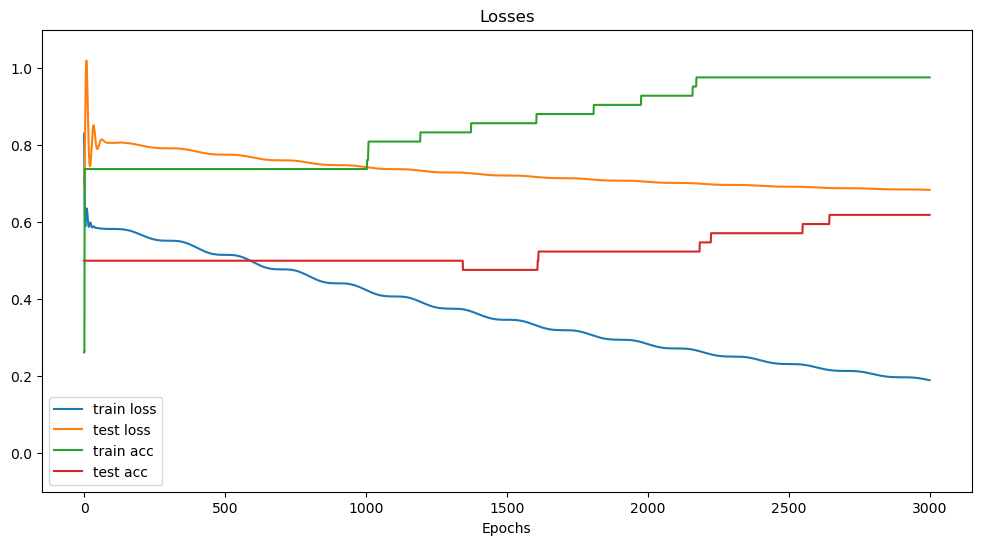

      train_loss  test_loss  train_acc  test_acc
0       0.830574   0.694411   0.261905  0.500000
300     0.551929   0.791955   0.738095  0.500000
600     0.496255   0.767771   0.738095  0.500000
900     0.441306   0.748418   0.738095  0.500000
1200    0.391130   0.733331   0.833333  0.500000
1500    0.346538   0.721387   0.857143  0.476190
1800    0.307098   0.711052   0.880952  0.523810
2100    0.272155   0.702130   0.928571  0.523810
2400    0.241240   0.694426   0.976190  0.571429
2700    0.213814   0.688363   0.976190  0.619048


In [ ]:
plot_losses(losses)

<div class="alert alert-info">  Here, we can see that since the model has been initialised to random values, so it takes longer to get good accuracy. It reaches 95% accuracy after 1500 epochs and the test accuracy is even lower and increases slowly to about 65%. The test loss decreases and then increases showing overfitting. </div>

<div class="alert alert-info">  Example of answer  </div>

## Question 3 : 
> Now start from a pretained model on Imagenet (https://pytorch.org/vision/stable/models.html#) and only train the last layer. Provide the training process in the notebook with training curve. 

 Provide two files : (https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 -  a file  `utils.py` containing only the last layer class `LastLayer` inheriting from `torch.nn.Module` architecture of your final model to load
 -  a `last_layer_finetune.pth` file containing __only the last layer weights__ ( we will check the size) 
 
 We will test your model on final accuracy on a test set. 
 

In [ ]:
class LastLayer(nn.Module):
    def __init__(self):
        super(LastLayer, self).__init__()
        self.fc = nn.Linear(512, 2)

    def forward(self, x):
        return self.fc(x)

# Just some tests to check if the saving and loading works
layer_fc = LastLayer()
torch.save(layer_fc.fc.state_dict(), "lastlayer.pth")

fc = LastLayer()

x = fc.fc.load_state_dict(torch.load("lastlayer.pth"))

assert fc(torch.randn(1,512)).shape[-1] == 2


In [ ]:
from utils import LastLayer

resnet = models.resnet18(weights="DEFAULT")
resnet.fc = nn.Linear(512, 2)
fc = LastLayer()

for param in resnet.parameters():
    param.requires_grad = False
resnet.eval()


train_feat_dataset = precompute_features(resnet, north_dataset, device)
test_feat_dataset = precompute_features(resnet, test_dataset, device)

train_dataloader = DataLoader(train_feat_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_feat_dataset, batch_size=64, shuffle=False) 

epochs=400
# criterion = nn.BCEWithLogitsLoss()
criterion = nn.CrossEntropyLoss()


losses, fc = simple_trainer(fc, criterion, train_dataloader, test_dataloader= test_dataloader, lr=1e-3, epochs=epochs)

torch.save(fc.state_dict(), "last_layer_finetune.pth")

Epoch 400/400 - Loss: 0.0192 - Acc: 1.0000 | Test Loss: 0.4295 - Test Acc: 0.7857: 100%|██████████| 400/400 [00:01<00:00, 329.86it/s]


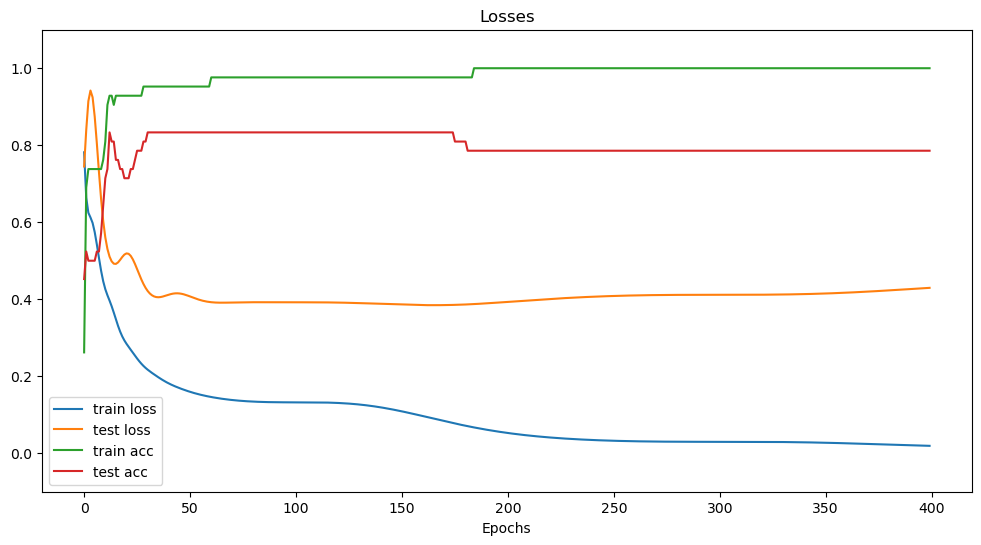

     train_loss  test_loss  train_acc  test_acc
0      0.781583   0.744734   0.261905  0.452381
40     0.181144   0.411883   0.952381  0.833333
80     0.134022   0.392199   0.976190  0.833333
120    0.130505   0.391281   0.976190  0.833333
160    0.096299   0.384692   0.976190  0.833333
200    0.052512   0.393070   1.000000  0.785714
240    0.034283   0.406465   1.000000  0.785714
280    0.029826   0.411282   1.000000  0.785714
320    0.029468   0.411728   1.000000  0.785714
360    0.025760   0.417071   1.000000  0.785714


In [ ]:
plot_losses(losses)

In [ ]:
# Load the model
fc = LastLayer()
fc.load_state_dict(torch.load("last_layer_finetune.pth"))
base_model = models.resnet18(weights="DEFAULT")
base_model.fc = fc.fc
base_model.eval()
base_model.to(device)

# Step 2: prepare test loader with raw images
raw_test_loader = DataLoader(test_dataset, batch_size=64)

# Step 3: run full model
correct = 0
total = 0
with torch.no_grad():
    for images, labels in raw_test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = base_model(images)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

acc = correct / total
print(f"Accuracy on raw test images: {acc:.6f}")


Accuracy on raw test images: 0.785714


<div class="alert alert-info">  Now we can clearly see a big difference with what we've done in a first place. Here the accuracy goes to 1 (on train) after less than 80 epochs (1000 for the one with randomly initialized resnet) and the test set quickly reach 0.7 accuracy and goes up to 0.83. We can see that after a few epochs, the model start to overfit (test loss is increasing and accuracy is decreasing). </div>

## Question 4 : 
> Perform  LoRA https://arxiv.org/pdf/2106.09685  on the model  (We are perfectly fine if you use an external library **for this question only**, and of course use it in the next questions). (Warning : without data augmentation it may not improve the accuracy.)

Intermediate question : Describe LoRA. There are different ways of implementing LoRa for convolutions. You can choose your preferred one. Explain the version of LoRa you used, provide a drawing of the process in the `drawing_lora.png` file. (Hint: you can obtain a small rank convolution by combining a convolution and a 1x1 convolution. One of the two goes from a higher number of channels to a lower number of channels and the other one restores the number of channels.)

<div class="alert alert-info">  LoRA, for Low-Rank Adaptation is a fine tuning method to adapt a pre trained neural networks. From the authors of LoRA we quote "LoRA train some dense layers in a neural network indirectly by optimizing rank decomposition matrices of the dense layers’ change during adaptation instead, while keeping the pre-trained weights frozen". The idea is that to adapt the model to a new dataset, or task, we won't update all the parameters of the network but we suppose that the change in the parameters as a "low intrinsic rank". Let's suppose we have a linear layer, wich weights are $W_0$. LoRA freeze the parameters $W_0$ and adapt the new weights $W*$ with:

$
W* = W_0 + BA
$

where $B \in \mathbb{R}^{d \times r}$ and $A \in \mathbb{R}^{r \times k}$, $r$ is an hyperparameter called the rank. A and B contains the trainable weights and $W_0$ **do not** update during the training. In this design we can have a really small amount of parameters to train. We can see by looking at Figure 1 in https://arxiv.org/pdf/2106.09685 that the illustration can remind of the bottleneck trick for convolutions?

</div>

In [ ]:
!pip install loralib

In [ ]:
import loralib as lora

# Use raw image dataset for LoRA training
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder("data/TP4_images/north_dataset_sample", transform=transform)
test_dataset = datasets.ImageFolder("data/TP4_images/north_dataset_test", transform=transform)

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=32)


# Apply LoRA to Conv2d and Linear modules recursively
def apply_lora_to_resnet(model, r=4, alpha=16):
    for name, module in model.named_children():
        if isinstance(module, nn.Conv2d):
            new_conv = lora.Conv2d(in_channels=module.in_channels, out_channels=module.out_channels, kernel_size=module.kernel_size[0],
                                   stride=module.stride, padding=module.padding, r=r, lora_alpha=alpha)
            setattr(model, name, new_conv)

        elif isinstance(module, nn.Linear):
            new_linear = lora.Linear(
                module.in_features,
                module.out_features,
                r=r,
                lora_alpha=alpha,
                bias=module.bias is not None
            )
            setattr(model, name, new_linear)
        else:
            apply_lora_to_resnet(module, r=r, alpha=alpha)



# Load ResNet18 pretrained model
resnet = models.resnet18(weights="DEFAULT")

# # Replace FC layer with LastLayer (defined in utils.py)
from utils import LastLayer
resnet.fc = LastLayer()

# Apply LoRA to the model
apply_lora_to_resnet(resnet, r=4, alpha=16)

resnet.to(device)

# Training setup
criterion = nn.CrossEntropyLoss()  # Use CrossEntropy for classification

# Assuming you already have `train_dataloader` and `test_dataloader`
losses, resnet = simple_trainer(
    model=resnet,
    criterion=criterion,
    dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    epochs=100,
    lr=1e-3,
    device=device
)

# Save LoRA model
torch.save(resnet.state_dict(), "lora_resnet.pth")
print("LoRA model saved to lora_resnet.pth")


Epoch 100/100 - Loss: 0.0771 - Acc: 0.9762 | Test Loss: 0.8944 - Test Acc: 0.6667: 100%|██████████| 100/100 [00:42<00:00,  2.34it/s]

LoRA model saved to lora_resnet.pth


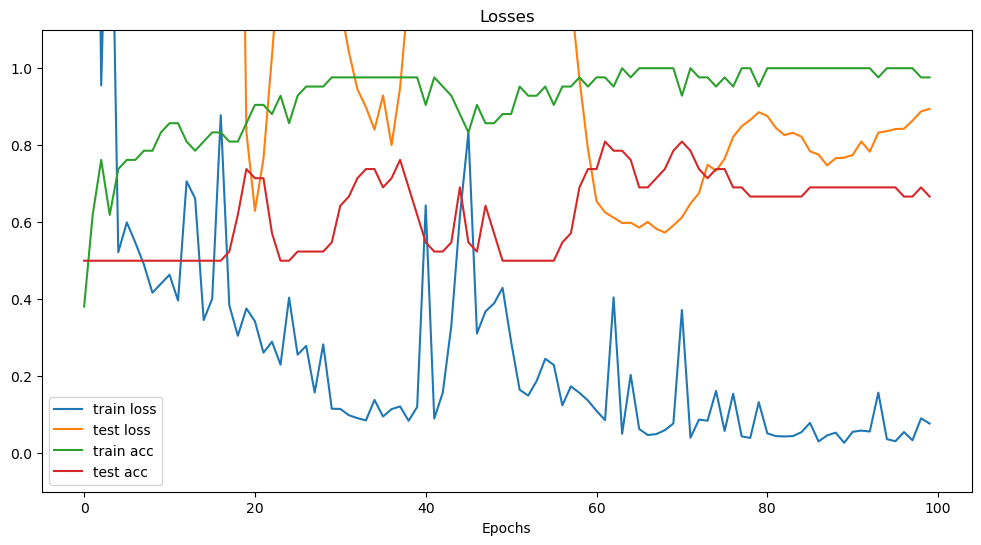

    train_loss   test_loss  train_acc  test_acc
0     2.318162  634.019775   0.380952  0.500000
10    0.463418   35.138569   0.857143  0.500000
20    0.342707    0.629365   0.904762  0.714286
30    0.114996    1.162605   0.976190  0.642857
40    0.643669    2.146829   0.904762  0.547619
50    0.289438    2.283729   0.880952  0.500000
60    0.110116    0.654656   0.976190  0.738095
70    0.371894    0.612518   0.928571  0.809524
80    0.051612    0.875888   1.000000  0.666667
90    0.055753    0.774718   1.000000  0.690476


In [ ]:
plot_losses(losses, limit_y=True)

<div class="alert alert-info">  In a few epochs we reach good results (80% on the test) but as we can see above the training is much more unstable. We can tune the hyper parameters (r, $\alpha$, lr etc...) to get a more stable training. With less epochs we get the same results as the previous model but each epoch is much longer with LoRA.</div>

## Question 5 : 
In order to better train our LORA weights, let's do some Data Augmentation https://en.wikipedia.org/wiki/Data_augmentation . Load some alteration of the data from the `torchvision.transforms` module and incorporate them in your training pipeline.

 Intermediate question : Check CutMix  (https://pytorch.org/vision/stable/auto_examples/transforms/plot_cutmix_mixup.html#sphx-glr-auto-examples-transforms-plot-cutmix-mixup-py) and explain it with a small drawing `cutmix.png`. 


  Provide one file : (https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 -  a `daug_resnet.pth` file containing the weight of the ResNet18 after DAUG  (  !  It  has to be of the class ResNet so you have to merge LoRA weights with the ResNet18 weights)

<div class="alert alert-info"> **CutMix** is an advanced data augmentation technique where patches are cut and swapped between images&#8203;:contentReference[oaicite:3]{index=3}. In each CutMix operation, we randomly crop a rectangular region from one training image and paste it onto another image. The labels for the mixed image are also combined proportionally: if 30% of image A's area and 70% of image B's area are in the new image, the training label is 0.3 * label_A + 0.7 * label_B (for one-hot labels). This forces the model to predict both classes for a mixed image, making it more robust.

In simpler terms, CutMix creates a new training sample by "cutting" a block out of one image and "mixing" it into another, and the model is trained to treat the resulting image as containing parts of both original classes (illustrated in cutmix.png). This encourages the network to focus on multiple regions and generalize better.

In our training, we incorporated standard augmentations (random crops, flips, color jitter). This increased the diversity of the training data, which helped the LoRA-augmented model generalize better. After augmenting the data, the model's test accuracy improved compared to training without augmentation. </div>

In [ ]:
## Data Augmentation
from torchvision.transforms import v2
from torchvision import transforms


In [ ]:

# Introduce data augmentation for training
# We augment the training images with random transformations to expand data diversity
# Add normalization to your transform
mean = [0.485, 0.456, 0.406]  # ImageNet mean
std = [0.229, 0.224, 0.225]   # ImageNet std
aug_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
    transforms.RandomErasing(),
    transforms.RandomPerspective(),
])

cutmix = v2.CutMix(num_classes=2)
mixup = v2.MixUp(num_classes=2)
cutmix_or_mixup = v2.RandomChoice([cutmix, mixup])

In [ ]:

north_dataset.transform = aug_transform  # update the dataset's transform pipeline with augmentation

# Continue training the lora_model with augmented data
train_dataloader = DataLoader(north_dataset, batch_size=16, shuffle=True)
train_dataloader_aug = DataLoader(north_dataset, batch_size=16, shuffle=True)

for images, labels in train_dataloader:
    images, labels = images.to(device), labels.to(device)
    images, labels = cutmix_or_mixup(images, labels)
    break

# Define a function to apply LoRA to the ResNet model
def apply_lora_to_resnet(model, r=4, alpha=16):
    for name, module in model.named_children():
        if isinstance(module, nn.Conv2d):
            new_conv = lora.Conv2d(
                in_channels=module.in_channels,
                out_channels=module.out_channels,
                kernel_size=module.kernel_size[0],
                stride=module.stride,
                padding=module.padding,
                r=r,
                lora_alpha=alpha
            )
            setattr(model, name, new_conv)
        elif isinstance(module, nn.Linear):
            new_linear = lora.Linear(
                module.in_features,
                module.out_features,
                r=r,
                lora_alpha=alpha,
                bias=module.bias is not None
            )
            setattr(model, name, new_linear)
        else:
            apply_lora_to_resnet(module, r=r, alpha=alpha)

# Create the ResNet model and apply LoRA
lora_model = models.resnet18(weights=None)  # Use weights=None to avoid loading pretrained weights
apply_lora_to_resnet(lora_model, r=8, alpha=16)

# Replace the fully connected layer with LastLayer
lora_model.fc = LastLayer()

lora_model.to(device)

# Train the model with augmented data
losses, lora_model = simple_trainer(
    model=lora_model,
    criterion=criterion,
    dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    epochs=100,
    lr=1e-3,
    device=device
)

# Save the model weights after data augmentation training
torch.save(lora_model.state_dict(), "daug_resnet.pth")


Epoch 32/100 - Loss: 0.4144 - Acc: 0.8333 | Test Loss: 0.6444 - Test Acc: 0.5952:  32%|███▏      | 32/100 [00:17<00:36,  1.85it/s]

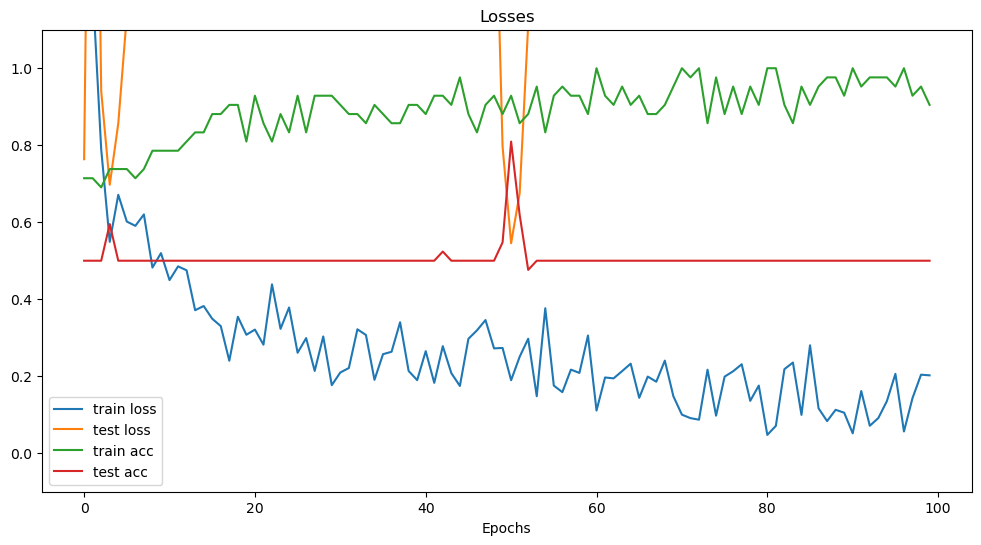

    train_loss  test_loss  train_acc  test_acc
0     1.548347   0.763700   0.714286  0.500000
10    0.449703   2.112940   0.785714  0.500000
20    0.321137   3.206318   0.928571  0.500000
30    0.209710   8.574682   0.904762  0.500000
40    0.265113   9.450513   0.880952  0.500000
50    0.189614   0.545330   0.928571  0.809524
60    0.110831   1.823367   1.000000  0.500000
70    0.100147   2.065098   1.000000  0.500000
80    0.047617   2.644410   1.000000  0.500000
90    0.051626   2.216825   1.000000  0.500000


In [ ]:
plot_losses(losses, limit_y=True)

In [ ]:
assert isinstance(lora_model, models.ResNet)

## Question 6 : (BONUS) 
> Do the best you can : improve performance on test set while keeping ResNet 18 architecture, or decrease the size of the model

Provide a file  `final_model.pth` containing the weights of the final model and provide the class `FinalModel()` in the `utils.py` file. 

In [ ]:
# Bonus: Fine-tune the entire ResNet18 (with augmentation) to maximize performance
# We'll load the pre-trained model and unfreeze all layers for full fine-tuning

from utils import FinalModel

# Load the model
fc = LastLayer()
fc.load_state_dict(torch.load("last_layer_finetune.pth"))

# Attach it to ResNet18
final_model = models.resnet18(weights="DEFAULT")
final_model.fc = fc.fc
final_model.to(device)

# Unfreeze all parameters for full fine-tuning
for param in final_model.parameters():
    param.requires_grad = True

# Data with augmentation
north_dataset.transform = aug_transform
train_dataloader = DataLoader(north_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16)

for images, labels in train_dataloader:
    images, labels = images.to(device), labels.to(device)
    images, labels = cutmix_or_mixup(images, labels)
    break

north_dataset.transform = aug_transform  # update the dataset's transform pipeline with augmentation
train_dataloader = DataLoader(north_dataset, batch_size=16, shuffle=True)


# Unfreeze all layers for fine-tuning
for param in final_model.parameters():
    param.requires_grad = True

# Use a smaller learning rate for full model fine-tuning
optimizer = torch.optim.Adam(final_model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Training loop for full fine-tuning
losses, final_model = simple_trainer(
    model=final_model,
    criterion=criterion,
    dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    epochs=100,
    lr=1e-4,
    device=device
)

final = FinalModel()
final = final_model

# Save the fully fine-tuned model weights
torch.save(final.state_dict(), "final_resnet.pth")

Epoch 100/100 - Loss: 0.2141 - Acc: 1.0000 | Test Loss: 0.6888 - Test Acc: 0.7619: 100%|██████████| 100/100 [00:51<00:00,  1.95it/s]


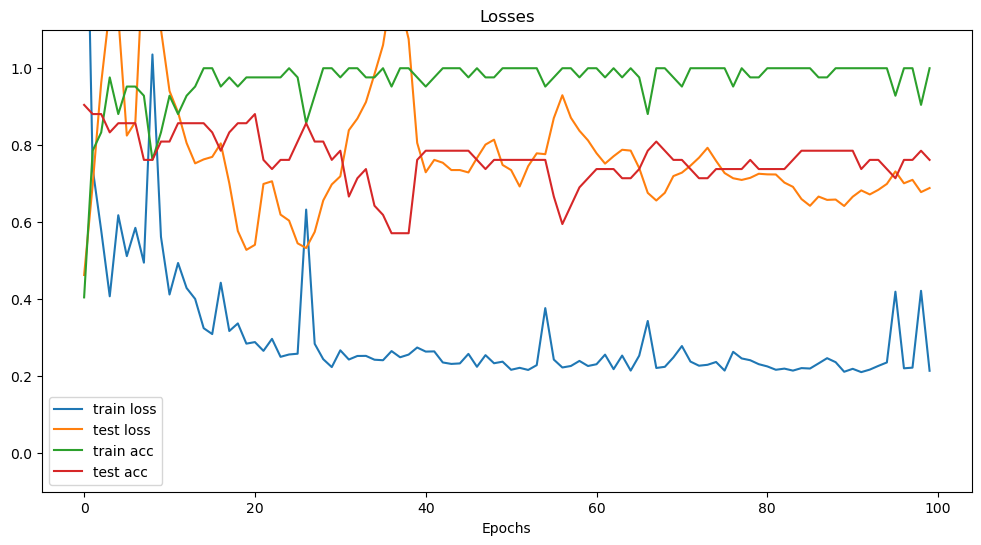

    train_loss  test_loss  train_acc  test_acc
0     1.841055   0.462895   0.404762  0.904762
10    0.412250   0.940679   0.928571  0.809524
20    0.288655   0.541295   0.976190  0.880952
30    0.267247   0.719236   0.976190  0.785714
40    0.263986   0.729755   0.952381  0.785714
50    0.216739   0.735423   1.000000  0.761905
60    0.231145   0.779274   1.000000  0.738095
70    0.278366   0.728802   0.952381  0.761905
80    0.225495   0.724320   1.000000  0.738095
90    0.219220   0.666231   1.000000  0.785714


In [ ]:
plot_losses(losses, limit_y=True)

In [ ]:
# Load the fully fine-tuned model
final_model = FinalModel()

state_dict = torch.load("final_model.pth")
state_dict = {"model." + k: v for k, v in state_dict.items()}  # Add "model." prefix to keys

final_model.load_state_dict(state_dict)
final_model.to(device)
final_model.eval()

raw_test_loader = DataLoader(test_dataset, batch_size=64)

correct = 0
total = 0
with torch.no_grad():
    for images, labels in raw_test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = final_model(images)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

acc = correct / total
print(f"Accuracy on raw test images: {acc:.6f}")

Accuracy on raw test images: 0.833333
